In [3]:
import os
import cv2
import pandas as pd
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization, Input, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, LearningRateScheduler, Callback
from sklearn.model_selection import train_test_split
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.applications import DenseNet201
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import tensorflow_addons as tfa

c:\Users\Lokesh\anaconda3\envs\radiolytica\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
c:\Users\Lokesh\anaconda3\envs\radiolytica\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.10.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file a

In [2]:
# Clear GPU memory before starting
def clear_gpu_memory():
    try:
        from numba import cuda
        device = cuda.get_current_device()
        device.reset()
    except:
        pass
    # Clear TensorFlow session
    tf.keras.backend.clear_session()
    # Enable memory growth to prevent TensorFlow from allocating all GPU memory at once
    physical_devices = tf.config.list_physical_devices('GPU')
    if physical_devices:
        for device in physical_devices:
            try:
                tf.config.experimental.set_memory_growth(device, True)
                print(f"Memory growth enabled for GPU device: {device}")
            except:
                print("Error enabling memory growth")

clear_gpu_memory()

Memory growth enabled for GPU device: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


In [3]:
# Set mixed precision policy for efficiency
try:
    from tensorflow.keras.mixed_precision import set_global_policy
    set_global_policy('mixed_float16')
    print("Mixed precision policy set to mixed_float16")
except:
    print("Couldn't set mixed precision policy")


INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 3050 Laptop GPU, compute capability 8.6
Mixed precision policy set to mixed_float16


In [4]:
def process_lung_image(image_path, mask_path=None, target_size=(224, 224)):
    """
    Process a lung image using a lung segmentation mask and radiological enhancements.
    Args:
        image_path (str): Path to the chest X-ray image.
        mask_path (str): Path to the lung mask (optional).
        target_size (tuple): Target size for resizing the image (224, 224 for classifier).
    Returns:
        Processed 3-channel RGB image for pneumonia classification.
    """
    # Load the original X-ray in grayscale
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {image_path}")
    
    # Resize to match model input size
    img_resized = cv2.resize(img, target_size)
    
    # If mask is provided, use it to segment lungs
    if mask_path and os.path.exists(mask_path):
        lung_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask_resized = cv2.resize(lung_mask, target_size)
        # Normalize the mask to 0-1 range
        mask_normalized = mask_resized / 255.0
        # Apply the lung mask to extract the lung regions
        segmented_lungs = img_resized * mask_normalized
    else:
        segmented_lungs = img_resized
    
    # Apply CLAHE for contrast enhancement (common in radiology)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = clahe.apply(segmented_lungs.astype(np.uint8))
    
    # Edge enhancement using Canny + Weighted Addition
    edges = cv2.Canny(img_clahe, 30, 100)
    img_edges = cv2.addWeighted(img_clahe, 1, edges, 0.2, 0)
    
    # Gaussian blur for noise reduction while preserving details
    img_filtered = cv2.GaussianBlur(img_edges, (3, 3), 0)
    
    # Normalize to 0-1 range
    img_normalized = img_filtered / 255.0
    
    # Convert to RGB (repeat grayscale image across 3 channels)
    img_rgb = np.repeat(img_normalized[:, :, np.newaxis], 3, axis=-1)
    
    return img_rgb

In [5]:
def _augment_function_improved(img, label):
    """
    Enhanced data augmentation for medical imaging.
    """
    # Random brightness and contrast adjustments (more medical-specific)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.5)

    # Random flips
    img = tf.image.random_flip_left_right(img)

    # Random rotation (specific for medical imaging)
    angle = tf.random.uniform([], -20, 20) * np.pi / 180
    img = tfa.image.rotate(img, angle)

    # Random zoom (simulates different distances from X-ray source)
    crop_size = tf.random.uniform([], 0.8, 1.0, dtype=tf.float32)
    img_shape = tf.shape(img)
    img_height, img_width = img_shape[0], img_shape[1]
    crop_height = tf.cast(tf.cast(img_height, tf.float32) * crop_size, tf.int32)
    crop_width = tf.cast(tf.cast(img_width, tf.float32) * crop_size, tf.int32)
    img = tf.image.random_crop(img, [crop_height, crop_width, 3])
    img = tf.image.resize(img, [224, 224])

    # Random Gaussian noise (simulates image sensor noise)
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=0.01)
    img = tf.clip_by_value(img + noise, 0.0, 1.0)

    return img, label

In [6]:
def create_tf_dataset_improved(image_paths, mask_paths, labels, batch_size, is_training=False):
    """
    Create an improved tf.data pipeline with better augmentation.
    Args:
        image_paths: List of image file paths.
        mask_paths: List of mask file paths (can be None).
        labels: List of labels (0 for normal, 1 for pneumonia).
        batch_size: Batch size for training.
        is_training: Whether to apply data augmentation.
    Returns:
        tf.data.Dataset object.
    """
    def _process_function(img_path, mask_path, label):
        # Convert tensor to string
        img_path_str = img_path.numpy().decode('utf-8')
        # Handle mask path (could be empty string)
        if tf.strings.length(mask_path) > 0:
            mask_path_str = mask_path.numpy().decode('utf-8')
        else:
            mask_path_str = None
        # Use the process_lung_image function
        processed_img = process_lung_image(img_path_str, mask_path_str)
        # Convert to tensor
        processed_img = tf.convert_to_tensor(processed_img, dtype=tf.float32)
        return processed_img, label

    def _tf_process_function(img_path, mask_path, label):
        # Wrap the function to use tf.py_function
        [processed_img, label] = tf.py_function(
            func=_process_function,
            inp=[img_path, mask_path, label],
            Tout=[tf.float32, tf.float32]
        )
        # Set shape information that gets lost in py_function
        processed_img.set_shape((224, 224, 3))
        label.set_shape(())
        return processed_img, label

    # Handle None values in mask_paths by replacing with empty strings
    mask_paths = ["" if path is None else path for path in mask_paths]

    # Convert lists to tensors
    image_paths = tf.constant(image_paths)
    mask_paths = tf.constant(mask_paths)
    labels = tf.constant(labels, dtype=tf.float32)

    # Create dataset
    dataset = tf.data.Dataset.from_tensor_slices((image_paths, mask_paths, labels))

    # Apply processing function
    dataset = dataset.map(_tf_process_function, num_parallel_calls=tf.data.AUTOTUNE)

    # Apply augmentation if training
    if is_training:
        dataset = dataset.map(_augment_function_improved, num_parallel_calls=tf.data.AUTOTUNE)

    # Shuffle if training
    if is_training:
        dataset = dataset.shuffle(buffer_size=1000)

    # Batch and prefetch
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset

In [7]:
# CyclicLR implementation for Phase 1
class CyclicLR(tf.keras.callbacks.Callback):
    def __init__(self, base_lr=0.0001, max_lr=0.001, step_size=2000, mode='triangular2', gamma=1., scale_fn=None, scale_mode='cycle'):
        super(CyclicLR, self).__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size = step_size
        self.mode = mode
        self.gamma = gamma
        if scale_fn is None:
            if self.mode == 'triangular':
                self.scale_fn = lambda x: 1.
                self.scale_mode = 'cycle'
            elif self.mode == 'triangular2':
                self.scale_fn = lambda x: 1 / (2. ** (x - 1))
                self.scale_mode = 'cycle'
            elif self.mode == 'exp_range':
                self.scale_fn = lambda x: gamma ** x
                self.scale_mode = 'iterations'
        else:
            self.scale_fn = scale_fn
            self.scale_mode = scale_mode
        self.clr_iterations = 0.
        self.trn_iterations = 0.
        self.history = {}

    def clr(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        if self.scale_mode == 'cycle':
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(cycle)
        else:
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(self.clr_iterations)

    def on_train_begin(self, logs=None):
        logs = logs or {}
        if self.clr_iterations == 0:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.base_lr)
        else:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.clr())

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.trn_iterations += 1
        self.clr_iterations += 1
        tf.keras.backend.set_value(self.model.optimizer.lr, self.clr())
        self.history.setdefault('lr', []).append(tf.keras.backend.get_value(self.model.optimizer.lr))
        self.history.setdefault('iterations', []).append(self.trn_iterations)
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = tf.keras.backend.get_value(self.model.optimizer.lr)


In [8]:
# CLMR: Cyclic Learning Rate and Momentum for Phase 2
class CLMR(tf.keras.callbacks.Callback):
    def __init__(self, base_lr=0.00001, max_lr=0.0001, base_momentum=0.85, max_momentum=0.95, step_size=2000, mode='triangular2'):
        super(CLMR, self).__init__()
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.base_momentum = base_momentum
        self.max_momentum = max_momentum
        self.step_size = step_size
        self.mode = mode
        self.clr_iterations = 0.
        self.trn_iterations = 0.
        self.history = {}

        if self.mode == 'triangular2':
            self.scale_fn = lambda x: 1 / (2. ** (x - 1))
            self.scale_mode = 'cycle'
        else:
            self.scale_fn = lambda x: 1.
            self.scale_mode = 'cycle'

    def clr(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        if self.scale_mode == 'cycle':
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(cycle)
        else:
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, (1 - x)) * self.scale_fn(self.clr_iterations)
    
    def cyclical_momentum(self):
        cycle = np.floor(1 + self.clr_iterations / (2 * self.step_size))
        x = np.abs(self.clr_iterations / self.step_size - 2 * cycle + 1)
        # Inverse relationship to LR - as LR increases, momentum decreases
        return self.max_momentum - (self.max_momentum - self.base_momentum) * np.maximum(0, (1 - x))

    def on_train_begin(self, logs=None):
        logs = logs or {}
        if self.clr_iterations == 0:
            tf.keras.backend.set_value(self.model.optimizer.lr, self.base_lr)
            if hasattr(self.model.optimizer, 'momentum'):
                tf.keras.backend.set_value(self.model.optimizer.momentum, self.max_momentum)

    def on_batch_end(self, batch, logs=None):
        logs = logs or {}
        self.trn_iterations += 1
        self.clr_iterations += 1
        
        lr = self.clr()
        tf.keras.backend.set_value(self.model.optimizer.lr, lr)
        
        if hasattr(self.model.optimizer, 'momentum'):
            momentum = self.cyclical_momentum()
            tf.keras.backend.set_value(self.model.optimizer.momentum, momentum)
            
        self.history.setdefault('lr', []).append(lr)
        self.history.setdefault('iterations', []).append(self.trn_iterations)
        
        if hasattr(self.model.optimizer, 'momentum'):
            self.history.setdefault('momentum', []).append(tf.keras.backend.get_value(self.model.optimizer.momentum))
            
        for k, v in logs.items():
            self.history.setdefault(k, []).append(v)
    
    def on_epoch_end(self, epoch, logs=None):
        logs = logs or {}
        logs['lr'] = tf.keras.backend.get_value(self.model.optimizer.lr)
        if hasattr(self.model.optimizer, 'momentum'):
            logs['momentum'] = tf.keras.backend.get_value(self.model.optimizer.momentum)

In [9]:
# Run the workflow
data_dir = r"C:\Users\Lokesh\Desktop\Radiolytica\Datasets\TB_Dataset"
output_dir = r"C:\Users\Lokesh\Desktop\Radiolytica\Tuberculosis"

batch_size = 16
epochs = 50

In [10]:

os.makedirs(output_dir, exist_ok=True)
model_path = os.path.join(output_dir, 'DenseNet201_TB_2.h5')
eval_output_dir = os.path.join(output_dir, 'evaluation_output_2')

try:
    # Load image paths
    normal_dir = os.path.join(data_dir, r'train\NORMAL\original')
    pneumonia_dir = os.path.join(data_dir, r'train\Tuberculosis\original')
    normal_mask_dir = os.path.join(data_dir, r'train\NORMAL\masks')
    pneumonia_mask_dir = os.path.join(data_dir, r'train\Tuberculosis\masks')
        
        # Check if mask directories exist
    has_normal_masks = os.path.exists(normal_mask_dir)
    has_pneumonia_masks = os.path.exists(pneumonia_mask_dir)
        
    # Initialize lists for data
    image_paths = []
    mask_paths = []
    labels = []
        
    # Process normal images
    print("Processing normal images...")
    for img_name in os.listdir(normal_dir):
        img_path = os.path.join(normal_dir, img_name)
            
        # Check if corresponding mask exists
        base_name = os.path.splitext(img_name)[0]
        mask_found = False
            
        if has_normal_masks:
            for ext in ['.png', '.jpg', '.jpeg']:
                potential_mask = os.path.join(normal_mask_dir, base_name + ext)
                if os.path.exists(potential_mask):
                    mask_paths.append(potential_mask)
                    mask_found = True
                    break
            
        # If no mask found, add empty string as placeholder
        if not mask_found:
            mask_paths.append("")
                
        # Add image path and label
        image_paths.append(img_path)
        labels.append(0)  # 0 for normal
            
    # Process pneumonia images
    print("Processing pneumonia images...")
    for img_name in os.listdir(pneumonia_dir):
        img_path = os.path.join(pneumonia_dir, img_name)
            
        # Check if corresponding mask exists
        base_name = os.path.splitext(img_name)[0]
        mask_found = False
            
        if has_pneumonia_masks:
            for ext in ['.png', '.jpg', '.jpeg']:
                potential_mask = os.path.join(pneumonia_mask_dir, base_name + ext)
                if os.path.exists(potential_mask):
                    mask_paths.append(potential_mask)
                    mask_found = True
                    break
            
        # If no mask found, add empty string as placeholder
        if not mask_found:
            mask_paths.append("")
                
        # Add image path and label
        image_paths.append(img_path)
        labels.append(1)  # 1 for pneumonia
        
        # Print statistics
    print(f"Number of normal images: {labels.count(0)}")
    print(f"Number of pneumonia images: {labels.count(1)}")
    print(f"Total images: {len(image_paths)}")
    print(f"Total masks: {len(mask_paths)}")
    print(f"Total labels: {len(labels)}")
        
    # Verify all arrays have the same length
    if not (len(image_paths) == len(mask_paths) == len(labels)):
        raise ValueError(f"Arrays have inconsistent lengths: images={len(image_paths)}, masks={len(mask_paths)}, labels={len(labels)}")
        
        # Standard train-val-test split (80% train, 10% val, 10% test)
    train_img, temp_img, train_mask, temp_mask, train_labels, temp_labels = train_test_split(
            image_paths, mask_paths, labels, test_size=0.2, stratify=labels, random_state=42)

    val_img, test_img, val_mask, test_mask, val_labels, test_labels = train_test_split(
            temp_img, temp_mask, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)

        # Print the split sizes to verify
    print(f"Training images: {len(train_img)}")
    print(f"Validation images: {len(val_img)}")
    print(f"Testing images: {len(test_img)}")
            
        # Create datasets
    train_dataset = create_tf_dataset_improved(train_img, train_mask, train_labels, batch_size, is_training=True)
    val_dataset = create_tf_dataset_improved(val_img, val_mask, val_labels, batch_size)
    test_dataset = create_tf_dataset_improved(test_img, test_mask, test_labels, batch_size)


except Exception as e:
    print(f"Error in main workflow: {e}")
    raise


Processing normal images...
Processing pneumonia images...
Number of normal images: 2625
Number of pneumonia images: 2625
Total images: 5250
Total masks: 5250
Total labels: 5250
Training images: 4200
Validation images: 525
Testing images: 525


In [4]:
input_shape = (224, 224, 3)  # Input shape for DenseNet201

base_model = tf.keras.applications.DenseNet201(
        include_top=False,
        weights='imagenet',
        input_shape=input_shape
    )
    
        
    # Set trainable property for all layers in base model
for layer in base_model.layers:
    layer.trainable = False
        # Wrap it in a named model
        # Create a wrapper model to make the base model accessible later
    
x = base_model.output
# Add classification layers on top of the base model
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
    
# Dense layers with L2 regularization
x = Dense(256, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
x = BatchNormalization()(x)
x = Dropout(0.4)(x)
    
# Final output layer
last_layer = Dense(1, activation='sigmoid', kernel_regularizer=tf.keras.regularizers.l2(0.001))(x)
    
# Create model using base_model's input and our output
model = Model(inputs=base_model.input, outputs=last_layer)
    
# Use Adam for Phase 1
optimizer = Adam(
        learning_rate=0.0001,  # Base learning rate (will be managed by CyclicLR)
        beta_1=0.9,
        beta_2=0.999,
        epsilon=1e-07
    )
    
model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ])

In [ ]:
model.summary()

Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 zero_padding2d (ZeroPadding2D)  (None, 230, 230, 3)  0          ['input_1[0][0]']                
                                                                                                  
 conv1/conv (Conv2D)            (None, 112, 112, 64  9408        ['zero_padding2d[0][0]']         
                                )                                                                 
                                                                                              

In [12]:
# Updated train function to use the new learning rate strategies

os.makedirs(os.path.dirname(model_path), exist_ok=True)
    
# Phase 1: Initial training with frozen base model using CyclicLR
print("Phase 1: Initial training with frozen base model using CyclicLR (triangular2)...")

    
# Calculate step_size for CyclicLR
# Rule of thumb: 2-10 times the number of iterations in an epoch
steps_per_epoch = len(train_dataset)
step_size = steps_per_epoch * 4  # 4 epochs per cycle
    
# Define callbacks for Phase 1
phase1_callbacks = [
        CyclicLR(
            base_lr=0.0002,
            max_lr=0.002,
            step_size=step_size,
            mode='triangular2'
        ),
        ModelCheckpoint(model_path, save_best_only=True, monitor='val_auc', mode='max', verbose=1),
        EarlyStopping(monitor='val_auc', patience=10, restore_best_weights=True,mode='max', verbose=1)
    ]
    
    # Initial training
initial_history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs //2,
        callbacks=phase1_callbacks,
        verbose=1
    )
    
# Phase 2: Fine-tuning with SGD and CLMR
print("\nPhase 2: Fine-tuning with partially unfrozen base model using CLMR...")

tf.keras.backend.clear_session()

base_model = load_model(model_path)
# Access to base model
base_model.trainable = True

for layer in base_model.layers[:100]:
    layer.trainable = False

# Switch to SGD with momentum for fine-tuning
optimizer = SGD(
        learning_rate=0.00001,  # Base learning rate for fine-tuning
        momentum=0.9,
        nesterov=True
    )
    
    # Recompile the model with SGD optimizer
model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='auc'),
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall')
        ]
    )
    
    # Calculate step_size for CLMR
step_size = steps_per_epoch * 3  # 3 epochs per cycle for fine-tuning
    
    # Define callbacks for Phase 2
phase2_callbacks = [
        CLMR(
            base_lr=0.00002,
            max_lr=0.0002,
            base_momentum=0.85,
            max_momentum=0.95,
            step_size=step_size,
            mode='triangular2'
        ),
        ModelCheckpoint(
            model_path,
            monitor='val_auc',
            save_best_only=True,
            mode='max',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_auc',
            patience=10,
            restore_best_weights=True,
            mode ='max',
            verbose=1
        ),
    ]

# Clear GPU memory before starting Phase 2
tf.keras.backend.clear_session()
    
# Fine-tuning
finetune_history = model.fit(
        train_dataset,
        validation_data=val_dataset,
        epochs=epochs//2,
        callbacks=phase2_callbacks,
        verbose=1
    )
    
    # Load the best model (either from phase 1 or phase 2)
best_model = tf.keras.models.load_model(model_path)
    
    # Combine histories
combined_history = {}
for key in initial_history.history:
    if key in finetune_history.history:
        combined_history[key] = initial_history.history[key] + finetune_history.history[key]
    else:
        combined_history[key] = initial_history.history[key]
    
history = tf.keras.callbacks.History()
history.history = combined_history
history.epoch = list(range(len(combined_history['loss'])))
    


Phase 1: Initial training with frozen base model using CyclicLR (triangular2)...
Epoch 1/25
263/263 [==============================] - ETA: 0s - loss: 0.8602 - accuracy: 0.7510 - auc: 0.8282 - precision: 0.7622 - recall: 0.7295
Epoch 1: val_auc improved from -inf to 0.89318, saving model to C:\Users\Lokesh\Desktop\Radiolytica\Tuberculosis\DenseNet201_TB_2.h5
263/263 [==============================] - 76s 202ms/step - loss: 0.8602 - accuracy: 0.7510 - auc: 0.8282 - precision: 0.7622 - recall: 0.7295 - val_loss: 0.6476 - val_accuracy: 0.8190 - val_auc: 0.8932 - val_precision: 0.8784 - val_recall: 0.7414 - lr: 6.5000e-04
Epoch 2/25
263/263 [==============================] - ETA: 0s - loss: 0.6899 - accuracy: 0.8012 - auc: 0.8772 - precision: 0.8130 - recall: 0.7824
Epoch 2: val_auc improved from 0.89318 to 0.90012, saving model to C:\Users\Lokesh\Desktop\Radiolytica\Tuberculosis\DenseNet201_TB_2.h5
263/263 [==============================] - 57s 198ms/step - loss: 0.6899 - accuracy: 0.8012

In [13]:
# Evaluate the model
def evaluate_model_improved(model, test_dataset, output_dir=None):
    y_pred_prob = []
    y_true = []

    for images, labels in test_dataset:
        batch_preds = model.predict(images, verbose=0)
        y_pred_prob.extend(batch_preds.flatten())
        y_true.extend(labels.numpy())

    y_pred_prob = np.array(y_pred_prob)
    y_true = np.array(y_true)

    y_pred = (y_pred_prob > 0.5).astype(int)

    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
    roc_auc = auc(fpr, tpr)

    evaluation_results = {
        'classification_report': report,
        'confusion_matrix': cm,
        'roc_auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'thresholds': thresholds
    }

    if output_dir:
        os.makedirs(output_dir, exist_ok=True)

        # Plot confusion matrix
        plt.figure(figsize=(10, 8))
        plt.imshow(cm, cmap='Blues')
        plt.title('Confusion Matrix')
        plt.ylabel('True Label')
        plt.xlabel('Predicted Label')
        classes = ['NORMAL', 'PNEUMONIA']
        tick_marks = np.arange(len(classes))
        plt.xticks(tick_marks, classes)
        plt.yticks(tick_marks, classes)
        thresh = cm.max() / 2
        for i in range(cm.shape[0]):
            for j in range(cm.shape[1]):
                plt.text(j, i, format(cm[i, j], 'd'),
                         ha="center", va="center",
                         color="white" if cm[i, j] > thresh else "black")
        plt.tight_layout()
        plt.savefig(os.path.join(output_dir, 'confusion_matrix_1.png'), dpi=200)

        # Plot ROC curve
        plt.figure(figsize=(10, 8))
        plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
        plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver Operating Characteristic (ROC) Curve')
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.savefig(os.path.join(output_dir, 'roc_curve_1.png'), dpi=200)

    return evaluation_results


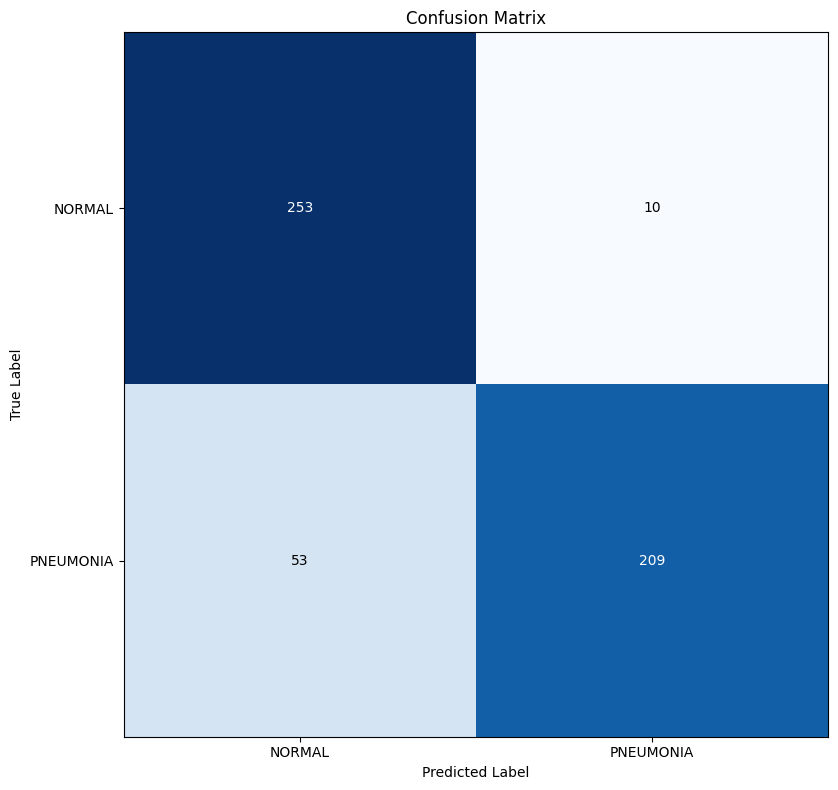

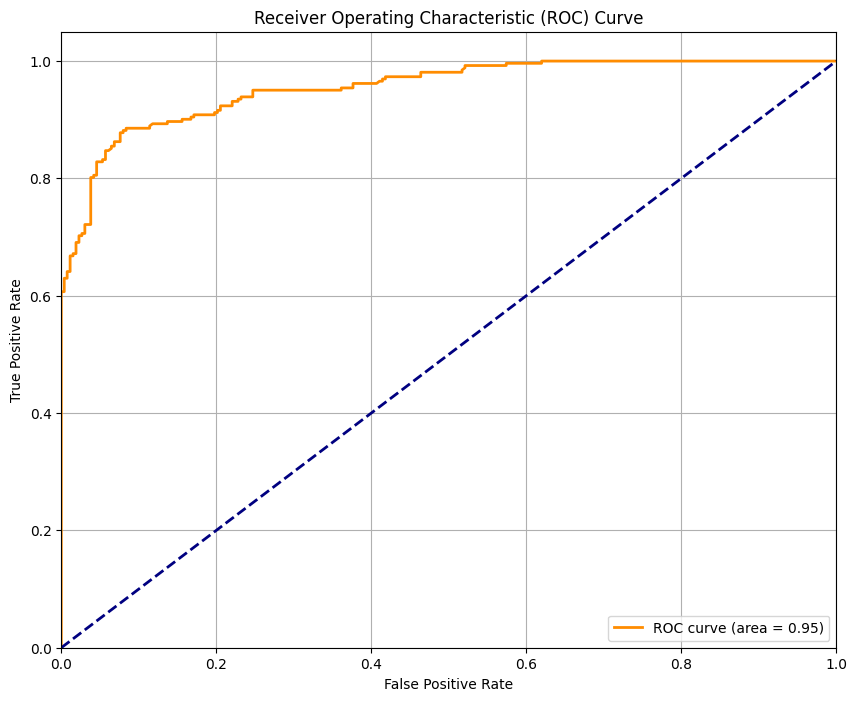

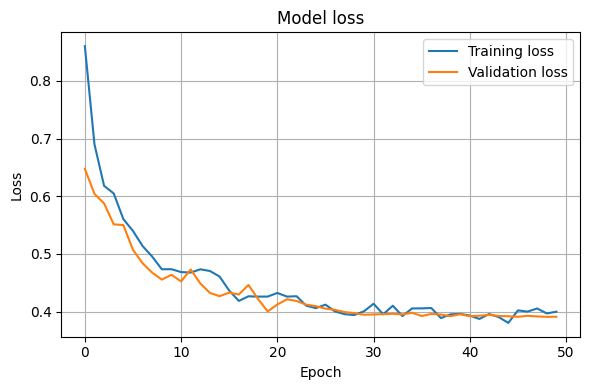

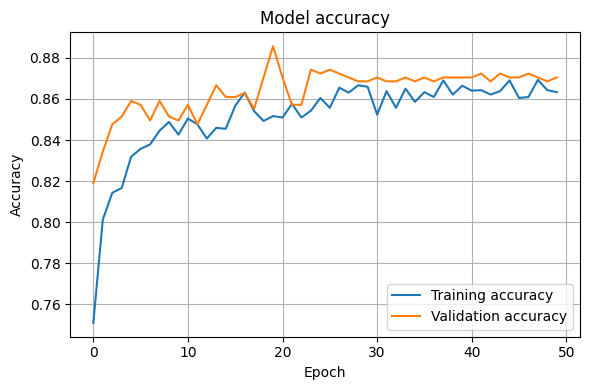

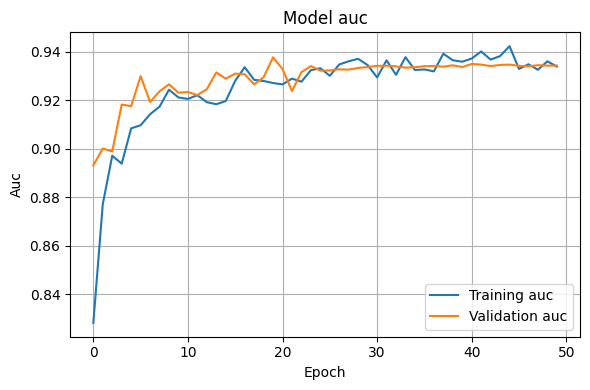

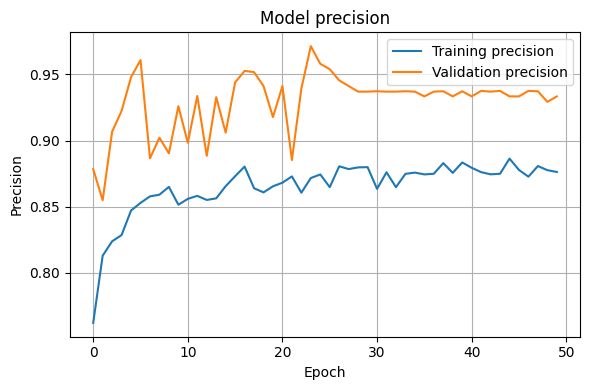

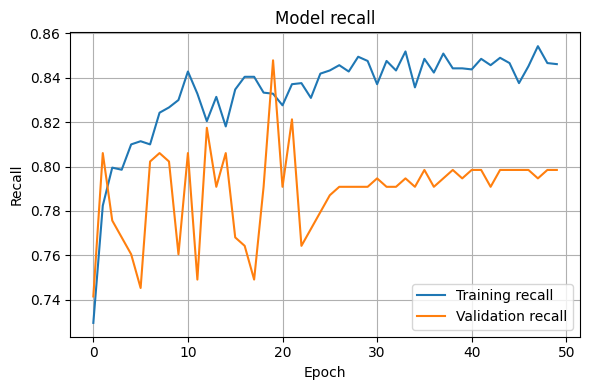

In [14]:
evaluation = evaluate_model_improved(model, test_dataset, eval_output_dir)

# Plot and save each metric separately
metrics = ['loss', 'accuracy', 'auc', 'precision', 'recall']

for metric in metrics:
    plt.figure(figsize=(6, 4))
    plt.plot(history.history[metric], label=f'Training {metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'Validation {metric}')
    plt.title(f'Model {metric}')
    plt.ylabel(metric.capitalize())
    plt.xlabel('Epoch')
    plt.legend(loc='best')
    plt.grid(True)
    plt.tight_layout()

    # Save each plot individually
    filename = f"training_history_{metric}.png"
    plt.savefig(os.path.join(output_dir, filename), dpi=200)
    plt.show()  # Show the plot inline (optional, remove if not needed)
